Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv("Walmart.csv")

View Dataset

In [3]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


Check Columns

In [5]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Check Missing Values

In [7]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

Basic Statistics

In [10]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Convert Date Column

In [12]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

Weekly Sales Trend

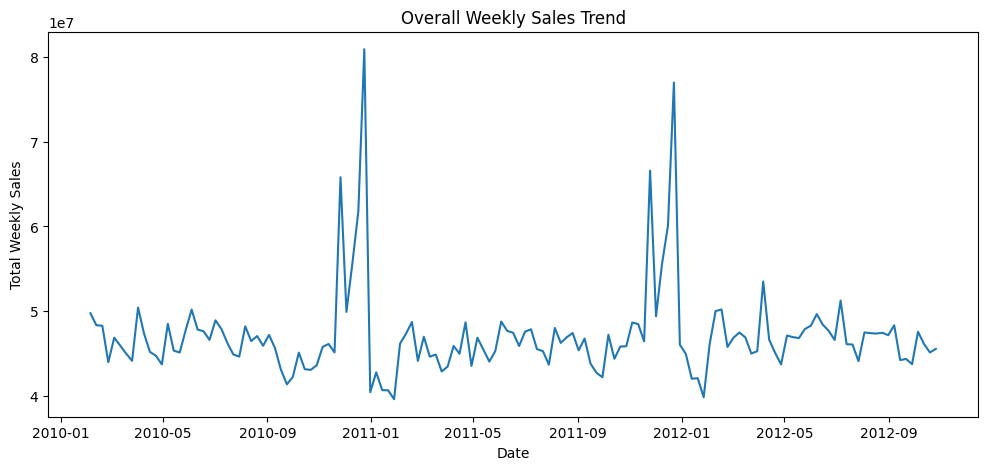

In [14]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(12,5))

plt.plot(sales_trend)

plt.title("Overall Weekly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Total Weekly Sales")

plt.show()

Sales by Store

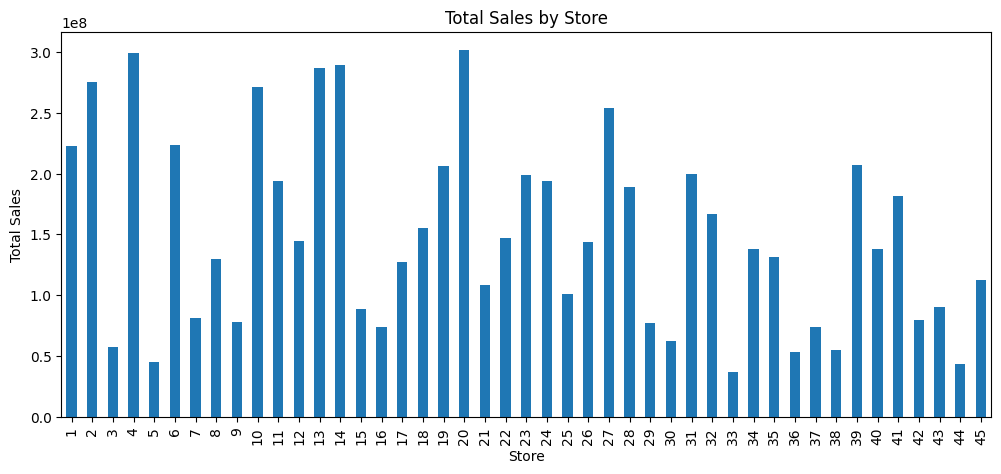

In [15]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum()

store_sales.plot(kind='bar', figsize=(12,5))

plt.title("Total Sales by Store")

plt.xlabel("Store")

plt.ylabel("Total Sales")

plt.show()

Holiday vs Non-Holiday Sales

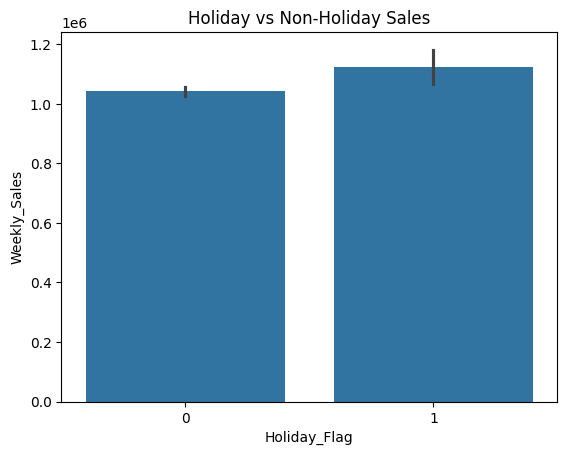

In [16]:
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df)

plt.title("Holiday vs Non-Holiday Sales")

plt.show()

Fuel Price vs Weekly Sales

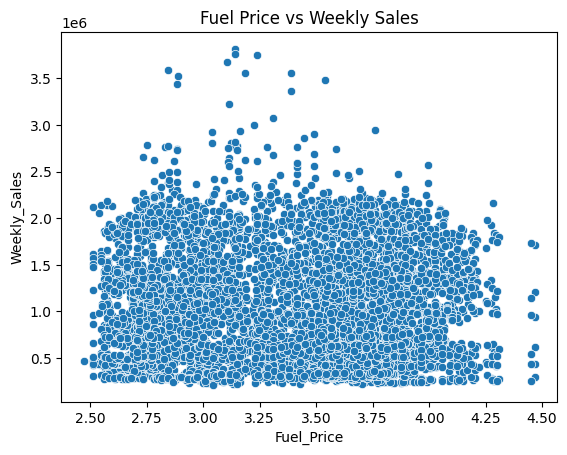

In [25]:
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df)

plt.title("Fuel Price vs Weekly Sales")

plt.show()

Monthly Sales Trend

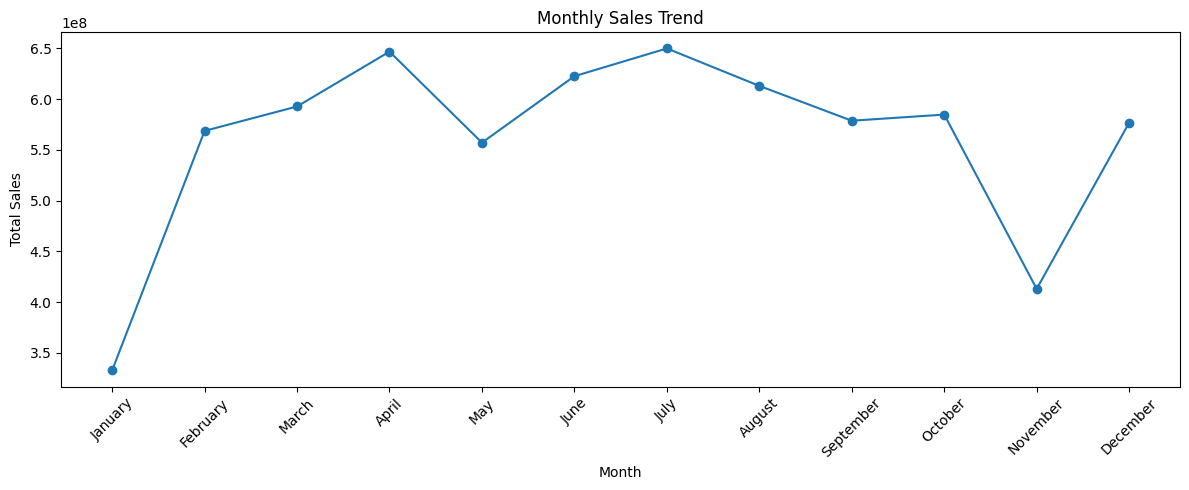

In [23]:
df['Month'] = df['Date'].dt.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum().reindex(month_order)

plt.figure(figsize=(12,5))

plt.plot(monthly_sales, marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Correlation Heatmap

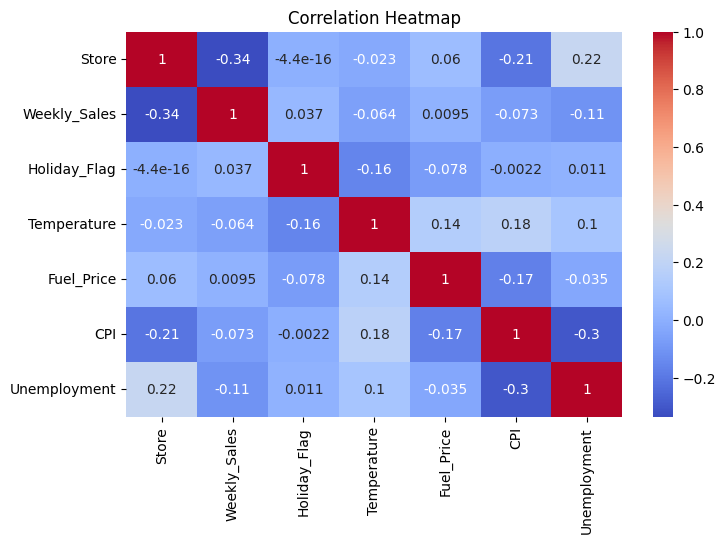

In [24]:
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Save Dataset

In [26]:
df.to_csv("cleaned_walmart_sales_data.csv", index=False)

Business Insights

1. Weekly sales showed fluctuations across different months.

2. Some stores generated significantly higher sales compared to others.

3. Holiday periods impacted weekly sales performance.

4. Fuel prices showed weak correlation with weekly sales.

5. Seasonal sales trends were observed during specific months.